In [2]:
using ITensors, ITensorMPS
using ITransverse
using Plots
using ProgressMeter

In [3]:
# System Parameters

# Alcaraz's NNN Self Dual Critical model
N = 50        
lambda = 1.0    # exact critical point (self dual)
p = 0.5         # NNN term (p>0 breakes system's integrability)
dt = 0.1       
T_max = 1.5     
cutoff = 1e-12
maxdim = 250

# Physical indices
sites = siteinds("S=1/2", N)

50-element Vector{Index{Int64}}:
 (dim=2|id=492|"S=1/2,Site,n=1")
 (dim=2|id=251|"S=1/2,Site,n=2")
 (dim=2|id=207|"S=1/2,Site,n=3")
 (dim=2|id=962|"S=1/2,Site,n=4")
 (dim=2|id=715|"S=1/2,Site,n=5")
 (dim=2|id=905|"S=1/2,Site,n=6")
 (dim=2|id=541|"S=1/2,Site,n=7")
 (dim=2|id=935|"S=1/2,Site,n=8")
 (dim=2|id=331|"S=1/2,Site,n=9")
 (dim=2|id=459|"S=1/2,Site,n=10")
 (dim=2|id=273|"S=1/2,Site,n=11")
 (dim=2|id=373|"S=1/2,Site,n=12")
 (dim=2|id=124|"S=1/2,Site,n=13")
 ⋮
 (dim=2|id=250|"S=1/2,Site,n=39")
 (dim=2|id=933|"S=1/2,Site,n=40")
 (dim=2|id=977|"S=1/2,Site,n=41")
 (dim=2|id=617|"S=1/2,Site,n=42")
 (dim=2|id=124|"S=1/2,Site,n=43")
 (dim=2|id=982|"S=1/2,Site,n=44")
 (dim=2|id=837|"S=1/2,Site,n=45")
 (dim=2|id=43|"S=1/2,Site,n=46")
 (dim=2|id=268|"S=1/2,Site,n=47")
 (dim=2|id=914|"S=1/2,Site,n=48")
 (dim=2|id=399|"S=1/2,Site,n=49")
 (dim=2|id=16|"S=1/2,Site,n=50")

Hamiltonian given by:
$$H = -\sum_i \left( \sigma_i^z \sigma_{i+1}^z + \lambda \sigma_i^x \mathbf{+} p \sigma_i^z \sigma_{i+2}^z + p \lambda \sigma_i^x \sigma_{i+1}^x \right)$$

In [4]:
# Hamiltonian

os = OpSum()

# Transverse magnetic field (X)
for j=1:N
    os += -lambda, "X", j
end

# Nearest-neighbour interactions (ZZ y XX)
for j=1:N-1
    os += -1.0, "Z", j, "Z", j+1
    os += -p*lambda, "X", j, "X", j+1
end

# Next-Nearest Neighbour interactions (ZZ)
for j=1:N-2
    os += -p, "Z", j, "Z", j+2
end

H = MPO(os, sites)
println("Max bond dim of Hamiltonian: ", maxlinkdim(H))

Max bond dim of Hamiltonian: 5


Progress: 100%|█████████████████████████████████████████| Time: 0:13:49


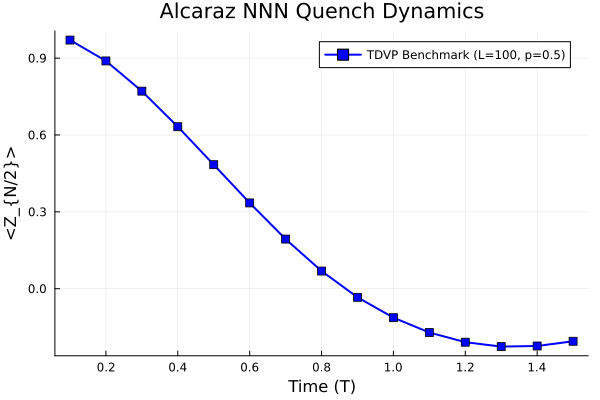

In [7]:
# Initial state: Up state
psi0 = MPS(sites, "Up")
psi_t = copy(psi0)

# We want to measure the observable Z in the middle of the chain
center_site = div(N, 2)
z_vals_tdvp = Float64[]
times = dt:dt:T_max

@showprogress for t in times
    global psi_t = tdvp(H, -im*dt, psi_t; cutoff=cutoff, maxdim=maxdim, nsweeps=2)
    
    val = expect(psi_t, "Z")[center_site]
    push!(z_vals_tdvp, real(val))
end

plot(times, z_vals_tdvp, 
     label="TDVP Benchmark (L=$N, p=$p)", 
     xlabel="Time (T)", 
     ylabel="<Z_{N/2}>",
     lw=2, color=:blue, marker=:square,
     title="Alcaraz NNN Quench Dynamics")

### Method 1: Trotterization

To build $U(\delta t) \approx e^{-i H \delta t}$ for the Alcaraz model, we will use a classic tensor network technique:

1. We first calculate the exact matrix exponential $e^{-i \delta t \cdot h}$ for every single term in the Hamiltonian independently.
2. For the NNN term ($Z_i Z_{i+2}$), the interaction "jumps over", so we mathematically sandwich an Identity matrix in the middle: $Z_i \otimes \mathbb{I}_{i+1} \otimes Z_{i+2}$.
3. We use 2nd-order Trotter expansion to reduce Trotter error.
4. At the end, we create an MPO representing a pure Identity matrix and we "apply" our array of gates to it (so that ITensors sweeps across the chain, absorbs the gates, and compresses the result into our final $U(\delta t)$ MPO).

In [5]:
# Custom Struct with our model's parameters
import ITransverse: ModelParams, modelparams

struct AlcarazModel <: ModelParams
    lambda::Float64
    p::Float64
    phys_site::Index
end

ITransverse.modelparams(mp::AlcarazModel) = (mp.lambda, mp.p)

function expH_alcaraz_v1(sites::Vector{<:Index}, lambda::Number, p::Number; dt::Number)
    N = length(sites)
    
    # 2nd order Trotterization
    dt_half = dt / 2.0

    gates = ITensor[]
    
    # Half-step NNN (Forward)
    for j=1:N-2
        h_NNN = -p * op("Z", sites[j]) * op("Id", sites[j+1]) * op("Z", sites[j+2])
        push!(gates, exp(-im * dt_half * h_NNN))
    end
    
    # Half-step NN (Forward)
    for j=1:N-1
        h_ZZ = -1.0 * op("Z", sites[j]) * op("Z", sites[j+1])
        h_XX = -p * lambda * op("X", sites[j]) * op("X", sites[j+1])
        push!(gates, exp(-im * dt_half * (h_ZZ + h_XX)))
    end
    
    # Full-step Transverse Field (Center)
    for j=1:N
        h_X = -lambda * op("X", sites[j])
        push!(gates, exp(-im * dt * h_X))
    end
    
    # Half-step NN (Reverse order for perfect symmetry)
    for j=N-1:-1:1
        h_ZZ = -1.0 * op("Z", sites[j]) * op("Z", sites[j+1])
        h_XX = -p * lambda * op("X", sites[j]) * op("X", sites[j+1])
        push!(gates, exp(-im * dt_half * (h_ZZ + h_XX)))
    end
    
    # Half-step NNN (Reverse order for perfect symmetry)
    for j=N-2:-1:1
        h_NNN = -p * op("Z", sites[j]) * op("Id", sites[j+1]) * op("Z", sites[j+2])
        push!(gates, exp(-im * dt_half * h_NNN))
    end
    
    U_dt = MPO(sites, "Id") 
    U_dt = apply(gates, U_dt; cutoff=1e-10, maxdim=200)
    
    return U_dt
end

expH_alcaraz_v1 (generic function with 1 method)

### Method 2: $\mathcal{O}(dt^3)$ Time-Evolution via the MPO $W^{II}$ Method

Standard approaches to time-evolution $U(dt) = e^{-i H dt}$ usually rely on Suzuki-Trotter decompositions, which split the Hamiltonian into non-overlapping spatial gates. Hoever, for the Alcaraz model, the NNN interactions ($Z_i \otimes \mathbb{I}_{i+1} \otimes Z_{i+2}$) span three sites. Attempting to Trotterize this geometry introduces severe commutativity errors.

Instead, we use the $W^{II}$ method (Zaletel et al.), which maps the Hamiltonian directly into a Finite State Machine (FSM) and applies a 2nd-order Taylor expansion globally.

**1. The Finite State Machine ($\hat{W}$)**
We map the Alcaraz interactions into 5 strictly forward-moving topological states:
1. **Start:** Initiates an interaction.
2. **Bridge:** The spatial gap ($\mathbb{I}$) for the NNN term.
3. **Wait Z:** Waiting to terminate a $ZZ$ or NNN term.
4. **Wait X:** Waiting to terminate an $XX$ term.
5. **End:** The interaction is complete.

This generates the optimally compressed, upper-triangular Hamiltonian MPO block $\hat{W}$:
$$ \hat{W} = \begin{pmatrix} 
\mathbb{I} & -p Z & -Z & -p\lambda X & -\lambda X \\ 
0 & 0 & \mathbb{I} & 0 & 0 \\ 
0 & 0 & 0 & 0 & Z \\ 
0 & 0 & 0 & 0 & X \\ 
0 & 0 & 0 & 0 & \mathbb{I} 
\end{pmatrix} \equiv \begin{pmatrix} \mathbb{I} & \hat{C} & \hat{D} \\ 0 & \hat{A} & \hat{B} \\ 0 & 0 & \mathbb{I} \end{pmatrix} $$

**2. The $W^{II}$ Taylor Expansion**
The time-evolution operator is constructed by applying the operator expansion $e^{-i H dt} \approx \mathbb{I} - i dt H - \frac{dt^2}{2}H^2$ directly to the FSM grid components. 
Crucially, overlapping interactions at a single site are captured by the matrix product $\hat{C}\hat{B}$. For the Alcaraz model, this non-commuting overlap is exactly equal to $-(1 + p\lambda)\mathbb{I}$. 

Substituting the blocks into the 2nd-order $W^{II}$ formula yields the exact MPO local tensor:
$$ W^{II}_{Alcaraz} = \begin{pmatrix} \mathbb{I} & -i dt \hat{C} & -i dt \hat{D} - \frac{dt^2}{2}\hat{C}\hat{B} \\ 0 & \hat{A} & \hat{B} \\ 0 & 0 & \mathbb{I} \end{pmatrix} = \begin{pmatrix} 
\mathbb{I} & i dt p Z & i dt Z & i dt p\lambda X & i dt \lambda X + \frac{dt^2}{2}(1 + p\lambda)\mathbb{I} \\ 
0 & 0 & \mathbb{I} & 0 & 0 \\ 
0 & 0 & 0 & 0 & Z \\ 
0 & 0 & 0 & 0 & X \\ 
0 & 0 & 0 & 0 & \mathbb{I} 
\end{pmatrix} $$

This tensor has a strictly constrained bond dimension of $\chi=5$ and natively integrates the 3-site NNN gap, completely avoiding automated SVD truncations, and executes with $\mathcal{O}(dt^3)$ precision.

In [6]:
# Custom Struct with our model's parameters
import ITransverse: ModelParams, modelparams

struct AlcarazModel <: ModelParams
    lambda::Float64
    p::Float64
    phys_site::Index
end

ITransverse.modelparams(mp::AlcarazModel) = (mp.lambda, mp.p)

function expH_alcaraz_v2(sites::Vector{<:Index}, lambda::Number, p::Number; dt::Number)
    N = length(sites)
    W_MPO = MPO(N)
    
    # We generate N+1 links of bond dim 5 (number of states required in the FSM matrix)
    links = [Index(5, "Link,l=$n") for n=0:N]
    
    for j = 1:N
        s = sites[j]
        ll = links[j]     # link n-1
        rl = links[j+1]   # Represents link n
        
        I_op = op("Id", s)
        Z_op = op("Z", s)
        X_op = op("X", s)
        
        # TENSOR TERMS:

        # Initialize
        W_j = (1.0 + 0.0im) * I_op * onehot(ll=>1, rl=>1)
        
        # C: Initial terms
        W_j += (im * dt * p) * Z_op * onehot(ll=>1, rl=>2)
        W_j += (im * dt) * Z_op * onehot(ll=>1, rl=>3)
        W_j += (im * dt * p * lambda) * X_op * onehot(ll=>1, rl=>4)
        
        # D: Local terms
        D = (im * dt * lambda) * X_op + (0.5 * dt^2 * (1.0 + p * lambda)) * I_op
        W_j += D * onehot(ll=>1, rl=>5)
        
        # A: Bridge term
        W_j += (1.0 + 0.0im) * I_op * onehot(ll=>2, rl=>3)

        # B: Final terms
        W_j += (1.0 + 0.0im) * Z_op * onehot(ll=>3, rl=>5)
        W_j += (1.0 + 0.0im) * X_op * onehot(ll=>4, rl=>5)
        W_j += (1.0 + 0.0im) * I_op * onehot(ll=>5, rl=>5)
        
        W_MPO[j] = W_j
    end
    
    # Bondary conditions:
    L_vec = (1.0 + 0.0im) * onehot(links[1] => 1)
    R_vec = (1.0 + 0.0im) * onehot(links[N+1] => 5)
    
    W_MPO[1] *= L_vec
    W_MPO[N] *= R_vec
    
    return W_MPO
end

expH_alcaraz_v2 (generic function with 1 method)

## Light Cone Evolution & Entropy

┌ Warning: ProgressMeter by default refresh meters with additional information in IJulia via `IJulia.clear_output`, which clears all outputs in the cell. 
│  - To prevent this behaviour, do `ProgressMeter.ijulia_behavior(:append)`. 
│  - To disable this warning message, do `ProgressMeter.ijulia_behavior(:clear)`.
└ @ ProgressMeter ~/.julia/packages/ProgressMeter/N660J/src/ProgressMeter.jl:607
[cone(v=1)|RTM_LR] [psi0 >> Op] cutoff=1.0e-12, maxdim=600) 100% Time: 0:00:17 ( 0.61  s/it)
   Info: [30] χ=19, (L|R) = 3.6995819037612404e-17 - 2.0804972008494195e-33im 


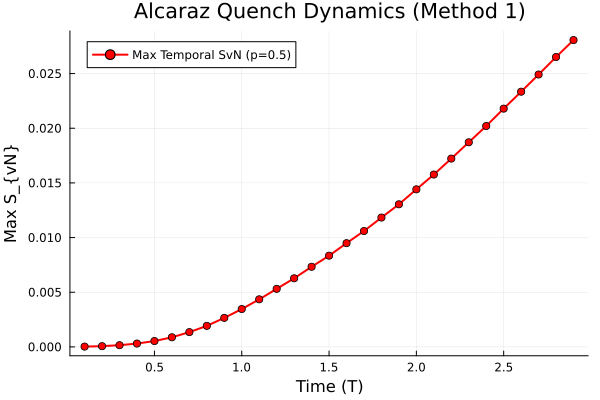

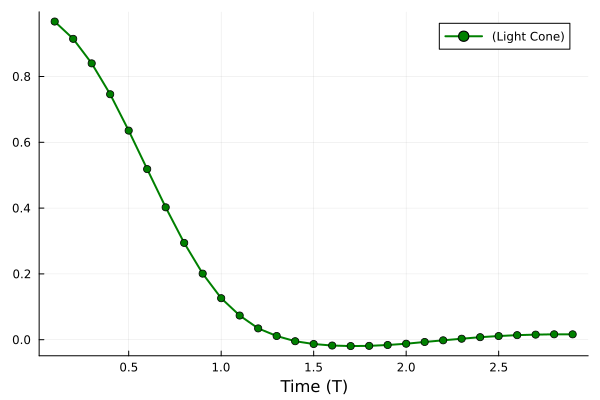

In [21]:
# Initial State (for Light Cone)
s = Index(2, "S=1/2")
bl = ITensor(ComplexF64, s)
bl[s => 1] = 1.0 + 0.0im  # Starting in the "Up" state

# Folded W Blocks
mp_alcaraz = AlcarazModel(lambda, p, s)

tp = tMPOParams(dt / 2.0, expH_alcaraz_v1, mp_alcaraz, 0, bl)
# tp = tMPOParams(dt / 2.0, expH_alcaraz_v2, mp_alcaraz, 0, bl)

fb = FoldtMPOBlocks(tp)

# Cone Parameters
t_params = TruncParams(cutoff, maxdim, "left")

cp = ConeParams(
    truncp = t_params,
    opt_method = "RTM_LR",       
    vwidth = 1                   
)

# Checkpoint to measure Von Neumann Entropy
chk = DoCheckpoint(
    "cp_alcaraz_entropy.jld2";
    params=tp,
    save_at=0, 
    observables = (
        SvN = s -> vn_entanglement_entropy(s.R), 
        Z_normed = s -> real(
            first(compute_expvals(s.L, s.R, ["Z"], s.b)["Z"]) / 
            first(compute_expvals(s.L, s.R, ["Id"], s.b)["Id"])
        )
    )
)

# Running simulation
init_mps = init_cone(fb, 1)
Nt_final = Int(round(T_max / dt))

L_final, R_final, checkpt = run_cone(init_mps, fb, cp, chk, Nt_final)

# Entropy
svn_vals_raw = checkpt.history[:SvN]
svn_max = [maximum(real(v)) for v in svn_vals_raw]

# 
z_vals = checkpt.history[:Z_normed]

times_plot = [n * dt for n in 1:length(svn_max)]

# Plot Ent Entropy
p1 = plot(times_plot, svn_max, 
     label="Max Temporal SvN (p=$p)", 
     xlabel="Time (T)", 
     ylabel="Max S_{vN}", 
     lw=2, color=:red, marker=:circle,
     title="Alcaraz Quench Dynamics (Method 1)")

display(p1)

# Plot 
p2 = plot(times_plot, z_vals, 
     label=" (Light Cone)", 
     xlabel="Time (T)", 
     ylabel="", 
     lw=2, color=:green, marker=:circle)

display(p2)
     

┌ Warning: ProgressMeter by default refresh meters with additional information in IJulia via `IJulia.clear_output`, which clears all outputs in the cell. 
│  - To prevent this behaviour, do `ProgressMeter.ijulia_behavior(:append)`. 
│  - To disable this warning message, do `ProgressMeter.ijulia_behavior(:clear)`.
└ @ ProgressMeter ~/.julia/packages/ProgressMeter/N660J/src/ProgressMeter.jl:607
[cone(v=1)|RTM_LR] [psi0 >> Op] cutoff=1.0e-12, maxdim=600) 100% Time: 0:00:06 ( 0.24  s/it)
   Info: [30] χ=10, (L|R) = 24.06006018310235 - 3.1616111687502245e-15im 


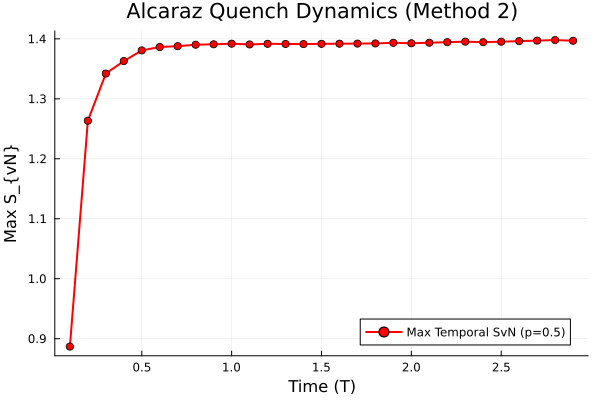

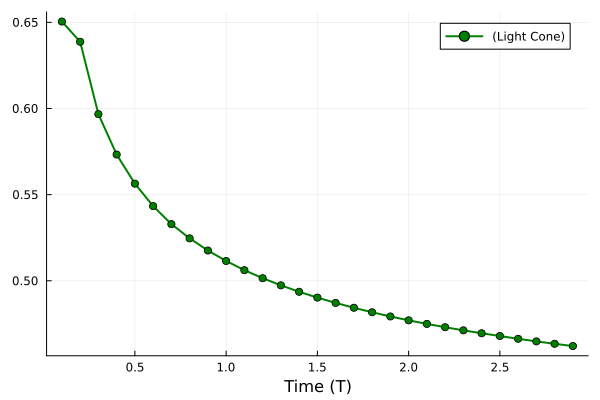

In [22]:
# Initial State (for Light Cone)
s = Index(2, "S=1/2")
bl = ITensor(ComplexF64, s)
bl[s => 1] = 1.0 + 0.0im  # Starting in the "Up" state

# Folded W Blocks
mp_alcaraz = AlcarazModel(lambda, p, s)

# tp = tMPOParams(dt / 2.0, expH_alcaraz_v1, mp_alcaraz, 0, bl)
tp = tMPOParams(dt / 2.0, expH_alcaraz_v2, mp_alcaraz, 0, bl)

fb = FoldtMPOBlocks(tp)

# Cone Parameters
t_params = TruncParams(cutoff, maxdim, "left")

cp = ConeParams(
    truncp = t_params,
    opt_method = "RTM_LR",       
    vwidth = 1                   
)

# Checkpoint to measure Von Neumann Entropy
chk = DoCheckpoint(
    "cp_alcaraz_entropy.jld2";
    params=tp,
    save_at=0, 
    observables = (
        SvN = s -> vn_entanglement_entropy(s.R), 
        Z_normed = s -> real(
            first(compute_expvals(s.L, s.R, ["Z"], s.b)["Z"]) / 
            first(compute_expvals(s.L, s.R, ["Id"], s.b)["Id"])
        )
    )
)

# Running simulation
init_mps = init_cone(fb, 1)
Nt_final = Int(round(T_max / dt))

L_final, R_final, checkpt = run_cone(init_mps, fb, cp, chk, Nt_final)

# Entropy
svn_vals_raw = checkpt.history[:SvN]
svn_max = [maximum(real(v)) for v in svn_vals_raw]

# Magnetization
z_vals = checkpt.history[:Z_normed]

times_plot = [n * dt for n in 1:length(svn_max)]

# Plot Ent Entropy
p1 = plot(times_plot, svn_max, 
     label="Max Temporal SvN (p=$p)", 
     xlabel="Time (T)", 
     ylabel="Max S_{vN}", 
     lw=2, color=:red, marker=:circle,
     title="Alcaraz Quench Dynamics (Method 2)")

display(p1)

# Plot 
p2 = plot(times_plot, z_vals, 
     label=" (Light Cone)", 
     xlabel="Time (T)", 
     ylabel="", 
     lw=2, color=:green, marker=:circle)

display(p2)
     